In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [5]:
df = pd.read_csv("data 3.csv")

In [6]:
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17


In [7]:
df.tail()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
62179,23,2017-03-18 18:42:28-07:00,67348,5,1,0,61.07,0,1,3,18
62180,21,2017-03-18 18:52:35-07:00,67955,5,1,0,61.07,0,1,3,18
62181,25,2017-03-18 19:02:40-07:00,68560,5,1,0,56.71,0,1,3,19
62182,18,2017-03-18 19:12:47-07:00,69167,5,1,0,56.71,0,1,3,19
62183,23,2017-03-18 19:22:51-07:00,69771,5,1,0,56.71,0,1,3,19


In [8]:
df.columns

Index(['number_people', 'date', 'timestamp', 'day_of_week', 'is_weekend',
       'is_holiday', 'temperature', 'is_start_of_semester',
       'is_during_semester', 'month', 'hour'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   date                  62184 non-null  str    
 2   timestamp             62184 non-null  int64  
 3   day_of_week           62184 non-null  int64  
 4   is_weekend            62184 non-null  int64  
 5   is_holiday            62184 non-null  int64  
 6   temperature           62184 non-null  float64
 7   is_start_of_semester  62184 non-null  int64  
 8   is_during_semester    62184 non-null  int64  
 9   month                 62184 non-null  int64  
 10  hour                  62184 non-null  int64  
dtypes: float64(1), int64(9), str(1)
memory usage: 6.7 MB


In [10]:
df.isnull().sum()

number_people           0
date                    0
timestamp               0
day_of_week             0
is_weekend              0
is_holiday              0
temperature             0
is_start_of_semester    0
is_during_semester      0
month                   0
hour                    0
dtype: int64

In [11]:
df["date"] = pd.to_datetime(df["date"],utc=True)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   number_people         62184 non-null  int64              
 1   date                  62184 non-null  datetime64[us, UTC]
 2   timestamp             62184 non-null  int64              
 3   day_of_week           62184 non-null  int64              
 4   is_weekend            62184 non-null  int64              
 5   is_holiday            62184 non-null  int64              
 6   temperature           62184 non-null  float64            
 7   is_start_of_semester  62184 non-null  int64              
 8   is_during_semester    62184 non-null  int64              
 9   month                 62184 non-null  int64              
 10  hour                  62184 non-null  int64              
dtypes: datetime64[us, UTC](1), float64(1), int64(9)
memory usage: 5.2 MB


In [13]:
df["date"]

0       2015-08-15 00:00:11+00:00
1       2015-08-15 00:20:14+00:00
2       2015-08-15 00:30:15+00:00
3       2015-08-15 00:40:16+00:00
4       2015-08-15 00:50:17+00:00
                   ...           
62179   2017-03-19 01:42:28+00:00
62180   2017-03-19 01:52:35+00:00
62181   2017-03-19 02:02:40+00:00
62182   2017-03-19 02:12:47+00:00
62183   2017-03-19 02:22:51+00:00
Name: date, Length: 62184, dtype: datetime64[us, UTC]

In [15]:
df["year"] = df["date"].dt.year

In [16]:
df["year"]

0        2015
1        2015
2        2015
3        2015
4        2015
         ... 
62179    2017
62180    2017
62181    2017
62182    2017
62183    2017
Name: year, Length: 62184, dtype: int32

In [17]:
 df.drop("date",axis=1,inplace=True)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   timestamp             62184 non-null  int64  
 2   day_of_week           62184 non-null  int64  
 3   is_weekend            62184 non-null  int64  
 4   is_holiday            62184 non-null  int64  
 5   temperature           62184 non-null  float64
 6   is_start_of_semester  62184 non-null  int64  
 7   is_during_semester    62184 non-null  int64  
 8   month                 62184 non-null  int64  
 9   hour                  62184 non-null  int64  
 10  year                  62184 non-null  int32  
dtypes: float64(1), int32(1), int64(9)
memory usage: 5.0 MB


In [19]:
df.head()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,61211,4,0,0,71.76,0,0,8,17,2015
1,45,62414,4,0,0,71.76,0,0,8,17,2015
2,40,63015,4,0,0,71.76,0,0,8,17,2015
3,44,63616,4,0,0,71.76,0,0,8,17,2015
4,45,64217,4,0,0,71.76,0,0,8,17,2015


/var/folders/xc/f0dz9wt11_l8wq0djgh1nhk00000gn/T/ipykernel_3189/1086912085.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x="hour",y="number_people",ci=None)


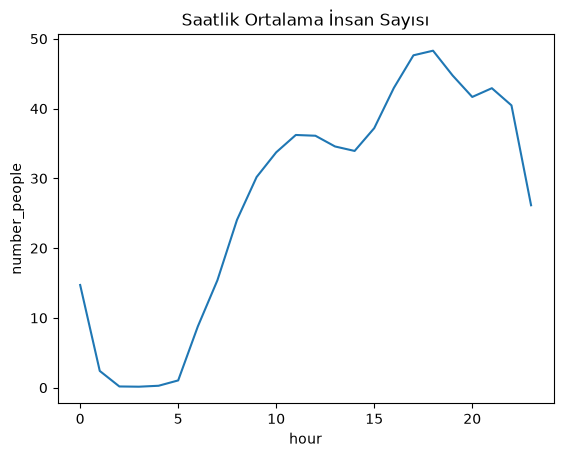

In [20]:
sns.lineplot(data=df, x="hour",y="number_people",ci=None)
plt.title("Saatlik Ortalama İnsan Sayısı")
plt.show()

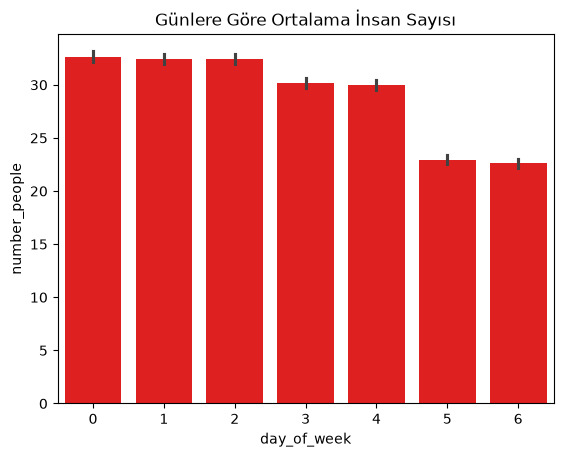

In [22]:
sns.barplot(data=df,x="day_of_week",y="number_people",color="red")
plt.title("Günlere Göre Ortalama İnsan Sayısı")
plt.show()

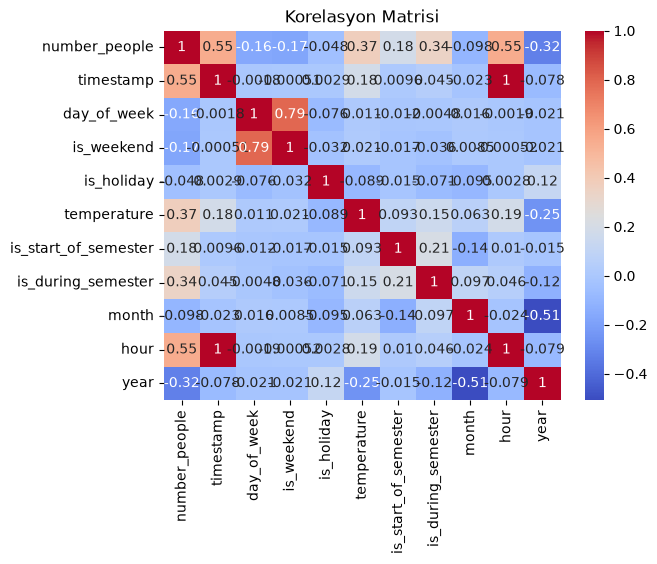

In [23]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Korelasyon Matrisi")
plt.show()

In [24]:
df.drop("timestamp",axis=1,inplace=True)

In [25]:
df.head()

,number_people,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,4,0,0,71.76,0,0,8,17,2015
1,45,4,0,0,71.76,0,0,8,17,2015
2,40,4,0,0,71.76,0,0,8,17,2015
3,44,4,0,0,71.76,0,0,8,17,2015
4,45,4,0,0,71.76,0,0,8,17,2015


In [26]:
X = df.drop("number_people",axis=1)
y = df["number_people"]

In [27]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=15)

In [30]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
def calculate_model_metrics(true,predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mean_squared_error(true,predicted))
    r2 = r2_score(true,predicted)
    return mae,rmse, r2

In [33]:
models = {
    "Linear Regression" : LinearRegression(),
    "Lasso" : Lasso(),
    "Ridge" : Ridge(),
    "Elastic Net" : ElasticNet(),
    "KNeighbors Regressor" : KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    "Random Forest Regressor" : RandomForestRegressor()
}

In [40]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse,model_train_r2 = calculate_model_metrics(y_train, y_train_pred)
    model_test_mae, model_test_rmse,model_test_r2 = calculate_model_metrics(y_test, y_test_pred)

    print(list(models.values())[i])
    print("Evalution for Training Set")
    print("RMSE :",model_train_rmse)
    print("Mean Absolute Error :",model_train_mae)
    print("R2 Score :",model_train_r2)

    print("------------------------")
    print(list(models.values())[i])
    print("Evalution for Test Set")
    print("RMSE :",model_test_rmse)
    print("Mean Absolute Error :",model_test_mae)
    print("R2 Score :",model_test_r2)

    print("------------------------")
    print("\n")

LinearRegression()
Evalution for Training Set
RMSE : 14.322500408269727
Mean Absolute Error : 10.733469936454329
R2 Score : 0.5999639521710997
------------------------
LinearRegression()
Evalution for Test Set
RMSE : 14.450632903370552
Mean Absolute Error : 10.779752371029563
R2 Score : 0.5989271376662773
------------------------


Lasso()
Evalution for Training Set
RMSE : 14.569122351126817
Mean Absolute Error : 10.945189874221992
R2 Score : 0.5860687429058037
------------------------
Lasso()
Evalution for Test Set
RMSE : 14.703511215751082
Mean Absolute Error : 10.970594902476911
R2 Score : 0.5847671974050241
------------------------


Ridge()
Evalution for Training Set
RMSE : 14.322500413912243
Mean Absolute Error : 10.733479178820696
R2 Score : 0.5999639518559021
------------------------
Ridge()
Evalution for Test Set
RMSE : 14.450633329986026
Mean Absolute Error : 10.77975955902301
R2 Score : 0.598927113985115
------------------------


ElasticNet()
Evalution for Training Set
RMSE

In [41]:
#hyperparameter tuning

In [42]:
knn_params = {"n_neighbors" : [2,3,10,20,40,50]}
rf_params = {
        "max_depth" : [5,8,10,15,None],
        "max_features" : ["sqrt", "log2", 5, 7, 10],
        "min_samples_split" : [2, 8, 12, 20],
        "n_estimators" : [100, 200, 500, 1000]
}

In [43]:
from sklearn.model_selection import RandomizedSearchCV

In [45]:
randomcv_models = [
    ("KNN", KNeighborsRegressor(), knn_params),
    ("RF", RandomForestRegressor(), rf_params)
]

In [49]:
for name, model, params in randomcv_models:
    randomcv = RandomizedSearchCV(estimator=model, param_distributions=params,n_iter = 100, cv=3,n_jobs=-1)
    randomcv.fit(X_train,y_train)
    print("Best Params for :",name, randomcv.best_params_)

/opt/anaconda3/lib/python3.14/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 6 is smaller than n_iter=100. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Params for : KNN {'n_neighbors': 2}


/opt/anaconda3/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params for : RF {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 7, 'max_depth': None}


In [50]:
models = {
    "K-Neighbors Regressor" : KNeighborsRegressor(n_neighbors=2),
    "Random Forest Regressor" : RandomForestRegressor(n_estimators=200,
                                                     min_samples_split=2,
                                                     max_features=7,
                                                     max_depth=None)
}

In [51]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse,model_train_r2 = calculate_model_metrics(y_train, y_train_pred)
    model_test_mae, model_test_rmse,model_test_r2 = calculate_model_metrics(y_test, y_test_pred)

    print(list(models.values())[i])
    print("Evalution for Training Set")
    print("RMSE :",model_train_rmse)
    print("Mean Absolute Error :",model_train_mae)
    print("R2 Score :",model_train_r2)

    print("------------------------")
    print(list(models.values())[i])
    print("Evalution for Test Set")
    print("RMSE :",model_test_rmse)
    print("Mean Absolute Error :",model_test_mae)
    print("R2 Score :",model_test_r2)

    print("------------------------")
    print("\n")

KNeighborsRegressor(n_neighbors=2)
Evalution for Training Set
RMSE : 5.457851670796327
Mean Absolute Error : 3.554633560615807
R2 Score : 0.9419095288948298
------------------------
KNeighborsRegressor(n_neighbors=2)
Evalution for Test Set
RMSE : 6.899544068227598
Mean Absolute Error : 4.636080020584073
R2 Score : 0.9085696618339064
------------------------


RandomForestRegressor(max_features=7, n_estimators=200)
Evalution for Training Set
RMSE : 4.713544025818393
Mean Absolute Error : 3.1981821123656893
R2 Score : 0.9566732037186545
------------------------
RandomForestRegressor(max_features=7, n_estimators=200)
Evalution for Test Set
RMSE : 6.42663634612749
Mean Absolute Error : 4.292653413228887
R2 Score : 0.9206737376289726
------------------------


